In [1]:
import pandas as pd

data = {
    "Age": [25, 30, 35, None, 40],
    "Salary": [50000, 60000, None, 80000, 90000],
    "Department": ["IT", "HR", "IT", "HR", None],
    "Purchased": ["No", "Yes", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         4 non-null      float64
 1   Salary      4 non-null      float64
 2   Department  4 non-null      str    
 3   Purchased   5 non-null      str    
dtypes: float64(2), str(2)
memory usage: 314.0 bytes


In [5]:
df.describe()

,Age,Salary
count,4.000000,4.000000
mean,32.500000,70000.000000
std,6.454972,18257.418584
min,25.000000,50000.000000
25%,28.750000,57500.000000
50%,32.500000,70000.000000
75%,36.250000,82500.000000
max,40.000000,90000.000000


In [6]:
df.isnull().sum()

Age           1
Salary        1
Department    1
Purchased     0
dtype: int64

In [11]:
df.fillna({'Age' : df['Age'].mean()}, inplace = True)

,Age,Salary,Department,Purchased
0,25.0,50000.0,IT,No
1,30.0,60000.0,HR,Yes
2,35.0,NaN,IT,Yes
3,32.5,80000.0,HR,No
4,40.0,90000.0,NaN,Yes


In [12]:
df.fillna({'Salary' : df['Salary'].mean()}, inplace = True)

,Age,Salary,Department,Purchased
0,25.0,50000.0,IT,No
1,30.0,60000.0,HR,Yes
2,35.0,70000.0,IT,Yes
3,32.5,80000.0,HR,No
4,40.0,90000.0,NaN,Yes


In [13]:
df.fillna({'Age' : df['Age'].mode()}, inplace = True)

,Age,Salary,Department,Purchased
0,25.0,50000.0,IT,No
1,30.0,60000.0,HR,Yes
2,35.0,70000.0,IT,Yes
3,32.5,80000.0,HR,No
4,40.0,90000.0,NaN,Yes


In [15]:
df.fillna({'Department' : df['Department'].mode()[0]}, inplace = True)

,Age,Salary,Department,Purchased
0,25.0,50000.0,IT,No
1,30.0,60000.0,HR,Yes
2,35.0,70000.0,IT,Yes
3,32.5,80000.0,HR,No
4,40.0,90000.0,HR,Yes


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [17]:
df_d = df.copy()

In [18]:
x = df_d.drop(['Age','Salary'], axis=1)

In [20]:
x

,Department,Purchased
0,IT,No
1,HR,Yes
2,IT,Yes
3,HR,No
4,HR,Yes


In [21]:
df_d['Department'] = le.fit_transform(df_d['Department'])

In [22]:
df_d

,Age,Salary,Department,Purchased
0,25.0,50000.0,1,No
1,30.0,60000.0,0,Yes
2,35.0,70000.0,1,Yes
3,32.5,80000.0,0,No
4,40.0,90000.0,0,Yes


In [23]:
df_d['Purchased'] = le.fit_transform(df_d['Purchased'])

In [24]:
df_d

,Age,Salary,Department,Purchased
0,25.0,50000.0,1,0
1,30.0,60000.0,0,1
2,35.0,70000.0,1,1
3,32.5,80000.0,0,0
4,40.0,90000.0,0,1


In [25]:
#it = 1, hr = 0, no=, yes = 1

In [27]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
df_d['Salary'] = ss.fit_transform(df_d['Salary'])

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [28]:
salmin = df_d['Salary'].min()
salmax = df_d['Salary'].max()
df_d['Salary'] = (df['Salary'] - salmin)/(salmax-salmin)

In [29]:
df_d

,Age,Salary,Department,Purchased
0,25.0,0.00,1,0
1,30.0,0.25,0,1
2,35.0,0.50,1,1
3,32.5,0.75,0,0
4,40.0,1.00,0,1


(array([1., 0., 0., 1., 0., 1., 1., 0., 0., 1.]),
 array([25. , 26.5, 28. , 29.5, 31. , 32.5, 34. , 35.5, 37. , 38.5, 40. ]),
 <BarContainer object of 10 artists>)

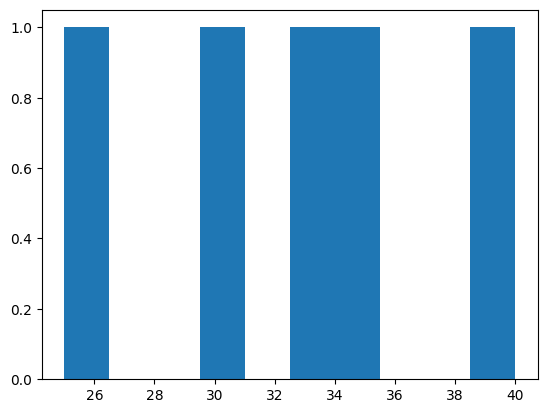

In [32]:
import matplotlib.pyplot as plt
plt.hist(df_d['Age'])

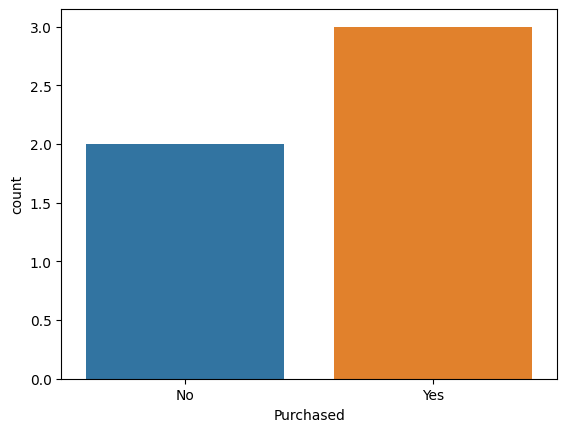

In [40]:
import seaborn as sns
sns.countplot(x="Purchased", data=df, order=["No", "Yes"])
plt.show()

In [35]:
df_d['Purchased']

0    0
1    1
2    1
3    0
4    1
Name: Purchased, dtype: int32

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (5,).

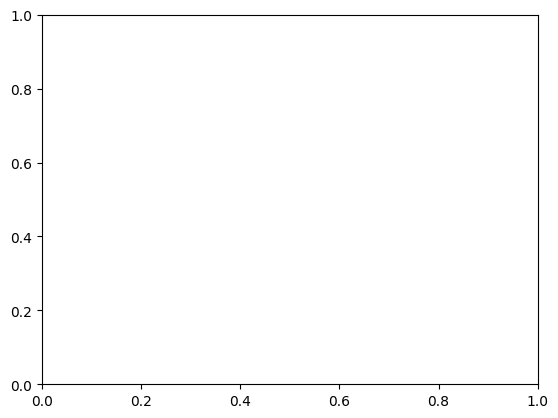

In [37]:
plt.bar([0,1], df_d['Purchased'])

In [41]:
from sklearn.model_selection import train_test_split

In [46]:
x = df.drop('Purchased', axis = 1)
y = df.Purchased
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

## Naive Bayes

In [69]:
data = {
    "Weather": ["Sunny", "Sunny", "Overcast", "Rain", "Rain"],
    "Temp": ["Hot", "Hot", "Hot", "Mild", "Cool"],
    "Play": ["No", "No", "Yes", "Yes", "Yes"]
}

In [70]:
df = pd.DataFrame(data)

In [71]:
from sklearn.naive_bayes import CategoricalNB
cnb = CategoricalNB()

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [73]:
df

,Weather,Temp,Play
0,Sunny,Hot,No
1,Sunny,Hot,No
2,Overcast,Hot,Yes
3,Rain,Mild,Yes
4,Rain,Cool,Yes


In [76]:
x = df.drop('Play', axis=1)
y = df.Play

In [78]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df_d = oe.fit_transform(x)

In [79]:
df_d

array([[2., 1.],
       [2., 1.],
       [0., 1.],
       [1., 2.],
       [1., 0.]])

In [80]:
cnb.fit(df_d, y)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [83]:
sample_data = pd.DataFrame([['Sunny','Cool']], columns = x.columns)

In [84]:
smenc = oe.fit_transform(sample_data)

In [85]:
print(cnb.predict(smenc)[0])

1


## Decision Tree

In [86]:
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain"],
    "Humidity": ["High","High","High","High","Normal"],
    "Play": ["No","No","Yes","Yes","Yes"]
}

In [87]:
df = pd.DataFrame(data)

In [88]:
df.head()

,Outlook,Humidity,Play
0,Sunny,High,No
1,Sunny,High,No
2,Overcast,High,Yes
3,Rain,High,Yes
4,Rain,Normal,Yes


In [89]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
enc = {}

for col in df.columns:
    df[col] = le.fit_transform(df[col])
    enc[col] = le
    
    print(f"Encoded for {col}")
    for i,l in enumerate(le.classes_):
        print(f"{l} = {i}")


Encoded for Outlook
Overcast = 0
Rain = 1
Sunny = 2
Encoded for Humidity
High = 0
Normal = 1
Encoded for Play
No = 0
Yes = 1


In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [93]:
x = df.drop('Play', axis=1)
y = df.Play
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

In [105]:
model = DecisionTreeClassifier(criterion="gini")

In [106]:
model = model.fit(x_train, y_train)

In [107]:
y_pred = model.predict(x_test)

In [108]:
accuracy_score(y_test, y_pred)

0.0

In [109]:
y_pred

array([1, 1])

In [110]:
y_test

1    0
0    0
Name: Play, dtype: int32

In [111]:
sample = [[0,0]]
print(model.predict(sample))

[1]


C:\Users\ASHMAN SODHI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## K Means

In [113]:
from sklearn.cluster import KMeans

In [114]:
X = [[1,2],[2,3],[3,4],[8,9],[9,10]]

In [133]:
import numpy as np
y = np.array([[2,3], [9,10]])
km = KMeans(n_clusters = 2, init=y, n_init=1)

In [134]:
km.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.","array([[ 2, ... [ 9, 10]])"
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [135]:
X = np.array(X)
dfx = pd.DataFrame(X, columns=['X','Y'])

In [136]:
dfx

,X,Y
0,1,2
1,2,3
2,3,4
3,8,9
4,9,10


In [137]:
km.fit(dfx)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.","array([[ 2, ... [ 9, 10]])"
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [138]:
dfx['Clusters'] = km.labels_

In [139]:
dfx

,X,Y,Clusters
0,1,2,0
1,2,3,0
2,3,4,0
3,8,9,1
4,9,10,1


In [140]:
km.cluster_centers_

array([[2. , 3. ],
       [8.5, 9.5]])

In [141]:
#Elbow method

In [154]:
cs = []
for i in range(1,5):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(dfx)
    cs.append(kmeans.inertia_)

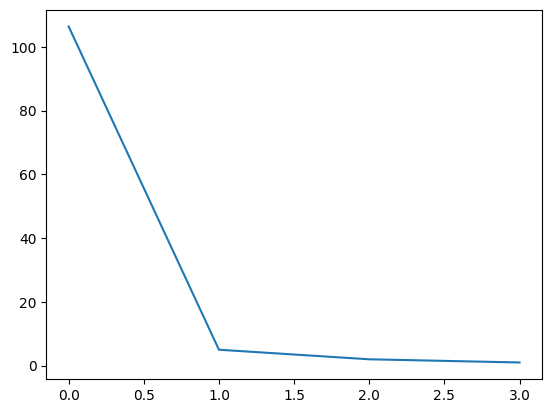

In [155]:
plt.plot(cs)

## K Medoid

In [148]:
from sklearn_extra.cluster import KMedoids

In [149]:
X = [[1,2],[2,3],[3,4],[8,9],[9,10]]
X = np.array(X)
dfx = pd.DataFrame(X, columns=['X','Y'])

In [150]:
dfx

,X,Y
0,1,2
1,2,3
2,3,4
3,8,9
4,9,10


In [151]:
initmed = np.array([[1,2],[9,10]])
kmm = KMedoids(n_clusters = 2, init = initmed, method='pam')

In [156]:
kmm.fit(dfx)

,n_clusters,2
,metric,'euclidean'
,method,'pam'
,init,"array([[ 1, ... [ 9, 10]])"
,max_iter,300
,random_state,None


In [157]:
dfx['C'] = kmm.labels_

In [158]:
kmm.cluster_centers_

array([[ 2.,  3.],
       [ 9., 10.]])

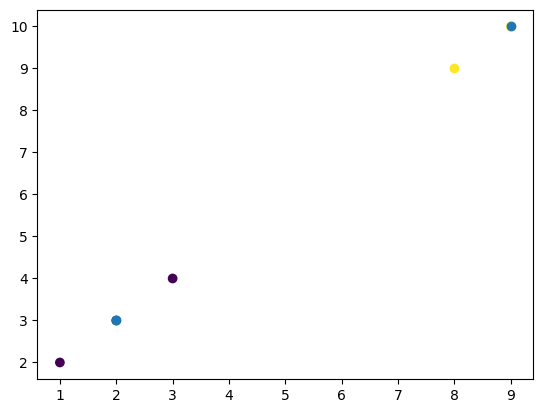

In [160]:
plt.scatter(dfx['X'], dfx['Y'], c=dfx['C'])
plt.scatter(kmm.cluster_centers_[:,0], kmm.cluster_centers_[:,1])
plt.show()

## DBSCAN

In [162]:
from itertools import combinations
import datetime as dt

def printDN():
    print(dt.datetime.now())
    print("Ashman Sodhi - 23BDS0068")
    
transactions = [
    {"Laptop", "Pendrive", "Harddisk", "CD"},
    {"Harddisk", "Pendrive", "Printer", "Mouse", "CD"},
    {"Printer", "Pendrive", "CD", "Mouse"},
    {"CD", "Pendrive", "Harddisk"}
]

min_support = 3
min_confidence = 0.8

def get_support(itemset):
    count = 0
    for transaction in transactions:
        if itemset.issubset(transaction):
            count += 1
    return count

def apriori():
    frequent = {}
    items = set()

    for t in transactions:
        for item in t:
            items.add(frozenset([item]))

    current_L = set()

    print("L1 Frequent Itemsets:")
    for item in items:
        support = get_support(item)
        if support >= min_support:
            frequent[item] = support
            current_L.add(item)
            print(set(item), "Support:", support)

    k = 2
    while current_L:
        print(f"\nL{k} Frequent Itemsets:")
        candidates = set()

        for i in current_L:
            for j in current_L:
                union = i.union(j)
                if len(union) == k:
                    candidates.add(union)

        next_L = set()
        for candidate in candidates:
            support = get_support(candidate)
            if support >= min_support:
                frequent[candidate] = support
                next_L.add(candidate)
                print(set(candidate), "Support:", support)

        current_L = next_L
        k += 1

    return frequent

def generate_rules(frequent):
    print("\nASSOCIATION RULES:")
    for itemset in frequent:
        if len(itemset) < 2:
            continue

        support_itemset = frequent[itemset]

        for i in range(1, len(itemset)):
            subsets = combinations(itemset, i)

            for antecedent in subsets:
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent

                support_antecedent = frequent[antecedent]
                confidence = support_itemset / support_antecedent

                if confidence >= min_confidence:
                    support_consequent = frequent.get(
                        consequent,
                        get_support(consequent)
                    )

                    lift = confidence / (support_consequent / len(transactions))

                    print(set(antecedent), "->", set(consequent))
                    

                    
frequent_itemsets = apriori()
generate_rules(frequent_itemsets)

L1 Frequent Itemsets:
{'Pendrive'} Support: 4
{'CD'} Support: 4
{'Harddisk'} Support: 3

L2 Frequent Itemsets:
{'Harddisk', 'CD'} Support: 3
{'Pendrive', 'CD'} Support: 4
{'Pendrive', 'Harddisk'} Support: 3

L3 Frequent Itemsets:
{'Harddisk', 'CD', 'Pendrive'} Support: 3

L4 Frequent Itemsets:

ASSOCIATION RULES:
{'Harddisk'} -> {'CD'}
{'Pendrive'} -> {'CD'}
{'CD'} -> {'Pendrive'}
{'Harddisk'} -> {'Pendrive'}
{'Harddisk'} -> {'Pendrive', 'CD'}
{'Harddisk', 'CD'} -> {'Pendrive'}
{'Harddisk', 'Pendrive'} -> {'CD'}


In [163]:
import datetime as dt

def printDN():
    print(dt.datetime.now())
    print("Ashman Sodhi - 23BDS0068")

class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None

    def increment(self, count):
        self.count += count

def build_header_table(transactions, min_support):
    header = {}

    # Count frequency
    for transaction in transactions:
        for item in transaction:
            header[item] = header.get(item, 0) + 1

    # Remove infrequent items
    header = {k: v for k, v in header.items() if v >= min_support}

    for item in header:
        header[item] = [header[item], None]

    return header

def insert_tree(items, node, header):
    if len(items) == 0:
        return

    first = items[0]

    if first in node.children:
        node.children[first].increment(1)
    else:
        new_node = FPNode(first, 1, node)
        node.children[first] = new_node

        if header[first][1] is None:
            header[first][1] = new_node
        else:
            current = header[first][1]
            while current.link is not None:
                current = current.link
            current.link = new_node

    insert_tree(items[1:], node.children[first], header)

def build_fp_tree(transactions, min_support):
    header = build_header_table(transactions, min_support)
    root = FPNode("NULL", 1, None)

    for transaction in transactions:
        filtered = []
        for item in transaction:
            if item in header:
                filtered.append(item)

        filtered.sort(key=lambda x: header[x][0], reverse=True)
        insert_tree(filtered, root, header)

    return root, header

def mine_tree(header, min_support, prefix, frequent_itemsets):
    sorted_items = sorted(header.items(), key=lambda x: x[1][0])

    for item, values in sorted_items:
        new_prefix = prefix.copy()
        new_prefix.add(item)

        frequent_itemsets.append((new_prefix, values[0]))

        conditional_patterns = []
        node = values[1]

        while node is not None:
            path = get_prefix_path(node)
            for i in range(node.count):
                conditional_patterns.append(path)
            node = node.link

        if len(conditional_patterns) > 0:
            cond_tree, cond_header = build_fp_tree(
                conditional_patterns,
                min_support
            )

            if cond_header:
                mine_tree(cond_header, min_support, new_prefix, frequent_itemsets)

def get_prefix_path(node):
    path = []

    while node.parent is not None:
        node = node.parent
        if node.item != "NULL":
            path.append(node.item)

    return path

transactions = [
    ['M', 'N', 'O', 'E', 'K', 'Y'],
    ['D', 'O', 'E', 'N', 'K', 'I'],
    ['M', 'A', 'K', 'E'],
    ['M', 'C', 'U', 'Y', 'K'],
    ['C', 'O', 'K', 'E', 'I']
]

min_support = 3

tree, header = build_fp_tree(transactions, min_support)

frequent_itemsets = []
mine_tree(header, min_support, set(), frequent_itemsets)

print("Frequent Itemsets using FP-Growth:\n")
for itemset, support in frequent_itemsets:
    print(itemset, "Support:", support)

Frequent Itemsets using FP-Growth:

{'M'} Support: 3
{'M', 'K'} Support: 3
{'O'} Support: 3
{'O', 'E'} Support: 3
{'O', 'K'} Support: 3
{'O', 'E', 'K'} Support: 3
{'E'} Support: 4
{'E', 'K'} Support: 4
{'K'} Support: 5


## DBSCAN

In [164]:
X = [[1,2],[2,2],[2,3],[8,8],[25,80]]
X = np.array(X)
dfx = pd.DataFrame(X, columns=['X','Y'])

In [165]:
from sklearn.cluster import DBSCAN

In [174]:
db = DBSCAN(eps=2, min_samples=2, metric='euclidean')
mod = db.fit(X)
label = mod.labels_
n_clust = len(set(label)) - (1 if -1 in label else 0)

In [175]:
print(n_clust)

1


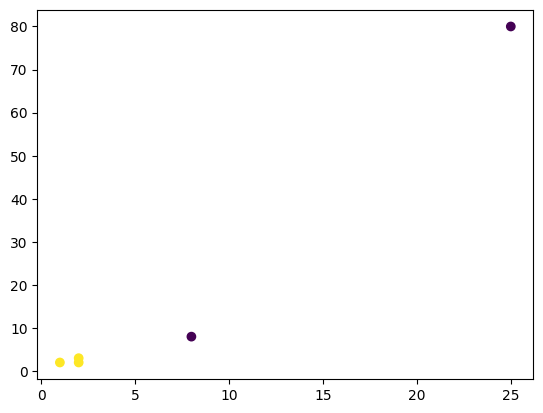

In [177]:
y_means = db.fit_predict(X)
plt.scatter(X[:, 0], X[:,1], c=y_means)

Cluster Labels: [ 0  0  0 -1 -1]


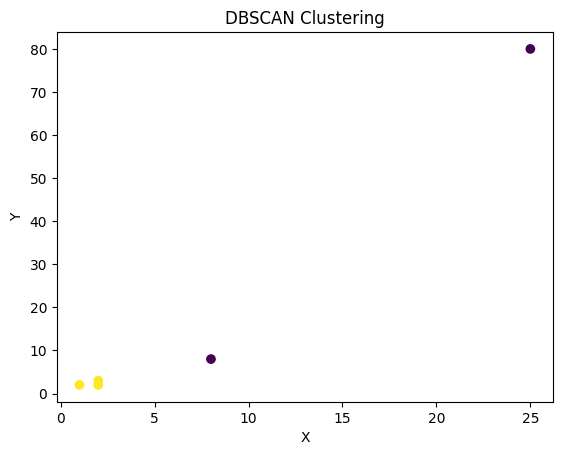

In [173]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([[1,2],[2,2],[2,3],[8,8],[25,80]])

# Model
db = DBSCAN(eps=2, min_samples=2)
labels = db.fit_predict(X)

print("Cluster Labels:", labels)

# Plotting
plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("DBSCAN Clustering")
plt.show()

## KNN

In [195]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

In [180]:
iris = load_iris()

In [182]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [185]:
X = iris.data
y = iris.target

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [188]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [190]:
y_pred = knn.predict(X_test)

In [191]:
print(accuracy_score(y_pred, y_test))

1.0


In [192]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[10  0  0]
 [ 0 11  0]
 [ 0  0  9]]


In [199]:
precision_score(y_test, y_pred, average='macro')

1.0

In [201]:
recall_score(y_test, y_pred, average='macro')

1.0